In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [7]:
!ls parameter_decoding/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only_kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only


relu0_param_decoding_pearsons_r2_by_augmentation_5e-01.png
relu0_param_decoding_r2_by_augmentation_5e-01.png
relu0_r2_decoding_values_ridge_alpha_5e-01.pkl
relu1_param_decoding_pearsons_r2_by_augmentation_5e-01.png
relu1_param_decoding_r2_by_augmentation_5e-01.png
relu1_r2_decoding_values_ridge_alpha_5e-01.pkl
relu2_param_decoding_pearsons_r2_by_augmentation_5e-01.png
relu2_param_decoding_r2_by_augmentation_5e-01.png
relu2_r2_decoding_values_ridge_alpha_5e-01.pkl
relu3_param_decoding_pearsons_r2_by_augmentation_5e-01.png
relu3_param_decoding_r2_by_augmentation_5e-01.png
relu3_r2_decoding_values_ridge_alpha_5e-01.pkl
relu4_param_decoding_pearsons_r2_by_augmentation_5e-01.png
relu4_param_decoding_r2_by_augmentation_5e-01.png
relu4_r2_decoding_values_ridge_alpha_5e-01.pkl
relufc_param_decoding_pearsons_r2_by_augmentation_5e-01.png
relufc_param_decoding_r2_by_augmentation_5e-01.png
relufc_r2_decoding_values_ridge_alpha_5e-01.pkl


In [10]:
results_pkls

[PosixPath('parameter_decoding/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only_kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only/relu4_r2_decoding_values_ridge_alpha_5e-01.pkl'),
 PosixPath('parameter_decoding/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only_kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only/relu2_r2_decoding_values_ridge_alpha_5e-01.pkl'),
 PosixPath('parameter_decoding/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only_kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only/relu3_r2_decoding_values_ridge_alpha_5e-01.pkl'),
 PosixPath('parameter_decoding/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only_kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only/relufc_r2_decoding_values_ridge_alpha_5e-01.pkl'),
 PosixPath('parameter_decoding/kell2018_barlow_equivariant_lmbda_1e

In [13]:
### Get results from dir

param_decoding_results_dir = Path("parameter_decoding")
results_pkls = list(param_decoding_results_dir.rglob("*audioset_only*/*_r2_decoding_values*.pkl"))

results_dfs = []
for ix, file_path in enumerate(results_pkls):
    results_dict = pd.read_pickle(file_path)
    # get files with ridge alpha in str 
    results_df = pd.DataFrame.from_dict(results_dict)
    results_df['parameter'] = results_df.index
    results_df.reset_index(drop=True)
    results_df['layer'] = file_path.stem.split('_r2')[0]
    results_df['model'] = 'ResNet18' if 'resnet18' in str(file_path) else 'Kell2018'
    eq_lmbda = 0.5 
    results_df['eq_lmbda'] = float(eq_lmbda)

    results_dfs.append(results_df)

    # if ix == 0:
    #     # mock invariant scores from first model as lmbda = 0.0 
    invar_df = results_df.copy(deep=True) 
    invar_df['eq_lmbda'] = 0.0 
    invar_df['ssl_training'] = 'invar.'
    invar_df['r2_equivariant'] = invar_df['r2_invariant']
    invar_df['pr2_equivariant'] = invar_df['pr2_invariant']
    results_dfs.append(invar_df)

    # break

results = pd.concat(results_dfs, axis=0, ignore_index = True).drop_duplicates()

In [14]:
results

,r2_invariant,r2_equivariant,pr2_invariant,pr2_equivariant,parameter,layer,model,eq_lmbda,ssl_training
0,0.794802,0.801134,0.795373,0.801438,dB SNR,relu4,Kell2018,0.5,NaN
1,0.412095,0.518486,0.440514,0.534089,Pitch (semitones),relu4,Kell2018,0.5,NaN
2,0.889331,0.892226,0.889496,0.892453,% Time warp,relu4,Kell2018,0.5,NaN
3,0.641308,0.802659,0.652917,0.806763,Filter order,relu4,Kell2018,0.5,NaN
4,0.735549,0.798518,0.737652,0.799568,Filter low cutoff,relu4,Kell2018,0.5,NaN
...,...,...,...,...,...,...,...,...,...
67,0.299856,0.299856,0.315477,0.315477,Pitch (semitones),relu0,Kell2018,0.0,invar.
68,0.888321,0.888321,0.888377,0.888377,% Time warp,relu0,Kell2018,0.0,invar.
69,0.492236,0.492236,0.504320,0.504320,Filter order,relu0,Kell2018,0.0,invar.
70,0.780641,0.780641,0.781881,0.781881,Filter low cutoff,relu0,Kell2018,0.0,invar.


## Plot Kell2018 models

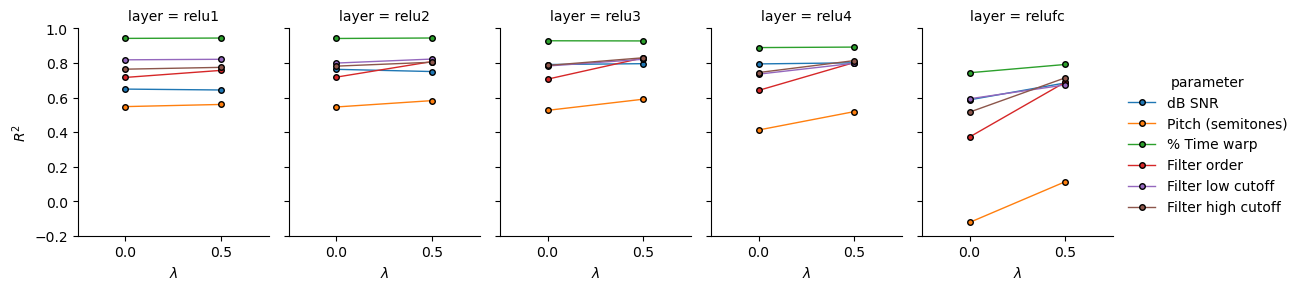

In [34]:
kell_results = results[results.model.str.contains('Kell')].reset_index(drop=True)

# fig, ax = plt.subplots(1, figsize=(6,4))
g = sns.catplot(
            kind='point',
            data=kell_results, # , [kell_results.layer=='relufc'],
            x='eq_lmbda',
            y='r2_equivariant',
            col='layer',
            col_order=
                ['relu1', 'relu2', 'relu3', 'relu4', 'relufc'],
            # col_wrap=3,
            # errorbar=('sd'),
            hue='parameter',
            # ax=ax,
            height=3,
            aspect=0.75,
            mec='k',
            mew=1,
            lw=1, 
            ms=4
)

g.set(ylabel='$R^2$', 
      xlabel='$\\lambda$',
      ylim=(-0.2,1),
        # fontsize=14,
        )
# g.legend(frameon=False, fontsize=10, title='Parameter', ncol=1)
# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True,dpi=500,  bbox_inches='tight')
